# Precision Banking & Predictive Modeling

## 1. Introduction

### 1.1 The Problem
In the modern Finance landscape, banks need to move beyond generalized marketing strategies. This project addresses a high stakes Binary Classification problem using a comprehensive dataset from a Portuguese banking institution. 

The goal is to predict whether a customer will subscribe to a term deposit following a direct marketing campaign. By identifying high-propensity customer profiles, this project enables banks to optimize resource allocation, reduce call fatigue, and significantly increase conversion rates for long-term investments.

### 1.2 Market Adaptation: Driving Value in the Kenyan Banking Sector
Despite the dataset originating from an international institution, the underlying business logic translates directly to the Kenyan financial landscape. 

For major players like KCB, Equity Bank, or NCBA, transitioning from mass outreach to data-driven precision is a strategic necessity.
- **Precision Marketing**: By moving away from expensive, broad spectrum SMS or telemarketing blasts, banks can target high-propensity individuals. This reduces operational overhead and prevents customer fatigue in a high-touch market.
- **Liquidity Management**: Predictable term deposit growth provides the stable capital required to fund long-term credit products such as mortgages and SME loans, which are the backbone of Kenya’s economic expansion.
- **Competitive Differentiation**: In a landscape dominated by mobile money (M-PESA) and Saccos, leveraging predictive analytics allows banks to deliver the right product at the optimal time, capturing market share in a highly competitive savings environment.


## 2. Import Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import joblib


from sklearn.utils import resample

from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score

### 2.1 About the Dataset
The dataset comprises 17 attributes, a mix of demographic, financial, and temporal variables that provide a 360-degree view of the bank's interaction with each client. They include both categorical and numerical data.

| Dimension | Features | Strategic Insight |
| :--- | :--- | :--- |
| **Demographics** | age, job, marital, education | Defines the customer segment and life-stage stability. |
| **Financial Health** | balance, default, housing, loan | Indicates disposable income and existing debt obligations. |
| **Current Campaign** | contact, day, month, duration, campaign | Captures the "how" and "when" of the current marketing effort. |
| **Historical Context** | pdays, previous, poutcome | Leverages past behavior to predict future receptivity. |



1. **age**: Age of the client (numeric)
2. **job**: Type of job (categorical: "admin.", "blue-collar", "entrepreneur", etc.)
3. **marital**: Marital status (categorical: "married", "single", "divorced")
4. **education**: Level of education (categorical: "primary", "secondary", "tertiary", "unknown")
5. **default**: Has credit in default? (categorical: "yes", "no")
6. **balance**: Average yearly balance in euros (numeric)
7. **housing**: Has a housing loan? (categorical: "yes", "no")
8. **loan**: Has a personal loan? (categorical: "yes", "no")
9. **contact**: Type of communication contact (categorical: "unknown", "telephone", "cellular")
10. **day**: Last contact day of the month (numeric, 1-31)
11. **month**: Last contact month of the year (categorical: "jan", "feb", "mar", …, "dec")
12. **duration**: Last contact duration in seconds (numeric)
13. **campaign**: Number of contacts performed during this campaign (numeric)
14. **pdays**: Number of days since the client was last contacted from a previous campaign (numeric; -1 means the client was not previously contacted)
15. **previous**: Number of contacts performed before this campaign (numeric)
16. **poutcome**: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")
17. **y**: The target variable, whether the client subscribed to a term deposit (binary: "yes", "no")


In [4]:
train = pd.read_csv("data/train.csv", index_col="id")
test = pd.read_csv("data/test.csv", index_col="id")

train.shape, test.shape

((750000, 17), (250000, 16))

In [5]:
train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


We identify the unique target classification variable.

In [6]:
# identifying the label column
for col in train.columns:
    if col not in test.columns:
        target = f"{col}"

target

'y'

## 3. Exploratory DA

Initial EDA confirms complete data or no missing values across both datasets.

In [7]:
# check for nulls
print(f" train data - {train.isnull().sum().sum()} missing values")
print(f" test data - {test.isnull().sum().sum()} missing values")

 train data - 0 missing values
 test data - 0 missing values


We start isolating text columns for conversion into numbers/encoding.

In [9]:
# identify features with object dtype
cat_cols = set()
for df in [train, test]:
    cat_cols.update(df.select_dtypes(include=['object']).columns)
        
cat_cols = list(cat_cols)
print(cat_cols)

['month', 'housing', 'job', 'default', 'loan', 'marital', 'education', 'contact', 'poutcome']


We standardize `job` entries and list unique categories for all non_numeric columns.

In [68]:
# display unique values for each categorical column in each dataset
for name, df in zip(["train_data", "test_data"], [train, test]):
    
    print(f"-------- {name} ---------")
    
    # clean the job column which has 'admin.' instead of 'admin'
    df['job'] = df['job'].str.replace('admin.', 'admin', regex=False)
    
    for col in df[cat_cols]:
        print(f"{col}: {df[col].nunique()} - {sorted(df[col].unique())}")        
    print()   


-------- train_data ---------
contact: 3 - ['cellular', 'telephone', 'unknown']
month: 12 - ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
default: 2 - ['no', 'yes']
poutcome: 4 - ['failure', 'other', 'success', 'unknown']
loan: 2 - ['no', 'yes']
marital: 3 - ['divorced', 'married', 'single']
housing: 2 - ['no', 'yes']
education: 4 - ['primary', 'secondary', 'tertiary', 'unknown']
job: 12 - ['admin', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

-------- test_data ---------
contact: 3 - ['cellular', 'telephone', 'unknown']
month: 12 - ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
default: 2 - ['no', 'yes']
poutcome: 4 - ['failure', 'other', 'success', 'unknown']
loan: 2 - ['no', 'yes']
marital: 3 - ['divorced', 'married', 'single']
housing: 2 - ['no', 'yes']
education: 4 - ['primary', 'secondary', 'tertiary',

There are 9 categorical features that have similar unique values for each dataset. We will encode these columns.

## 4. Feature Engineering and Encoding

New variables will translate raw data into unseen customer behaviors and financial patterns to improve model accuracy. These features help to better predict subscription likelihood.

In [ ]:
# Binary & Behavioral Flags
for df in [train, test]:
    df['is_new_customer'] = (df['pdays'] == -1).astype(int)
    df['has_debt'] = ((df['housing'] == 1) | (df['loan'] == 1)).astype(int)
    df['is_exhausted'] = (df['campaign'] > 3).astype(int)
    df['is_senior'] = (df['age'] > 60).astype(int)
    df['is_youth'] = (df['age'] < 25).astype(int)
    
    payday_days = [1, 2, 3, 4, 5, 15, 16, 17, 18, 19, 20]
    df['is_payday_prox'] = df['day'].isin(payday_days).astype(int)
    
    # Reciprocal of pdays (Momentum); handles -1 naturally by returning 0
    df['engagement_momentum'] = df['pdays'].apply(lambda x: 1/(x+1) if x > 0 else 0)

# Log Transforms (Fixed Offset)
balance_offset = abs(train['balance'].min()) + 1
for df in [train, test]:
    df['log_balance'] = np.log1p(df['balance'] + balance_offset)
    df['log_duration'] = np.log1p(df['duration'])
    df['conversion_intent'] = df['log_balance'] * df['log_duration']

# Relative Liquidity (No-Merge Transform)
# Calculate stats on TRAIN
edu_stats = train.groupby('education')['balance'].agg(['mean', 'std'])
mean_map = edu_stats['mean'].to_dict()
std_map = edu_stats['std'].to_dict()

# Apply to TRAIN using transform for speed/index safety
train['rel_liquidity'] = (train['balance'] - train.groupby('education')['balance'].transform('mean')) / \
                         (train.groupby('education')['balance'].transform('std') + 1)

# Apply to TEST using the TRAIN maps to prevent leakage
test['rel_liquidity'] = (test['balance'] - test['education'].map(mean_map)) / \
                        (test['education'].map(std_map) + 1)



Next, we convert our 9 categorical variables, identified above, into numerical formats. This process will involve mapping simple yes or no responses to binary digits, creating separate indicators for job types, and ranking education levels by their academic progression.

In [11]:
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    train[col] = train[col].map({'no': 0, 'yes': 1})
    test[col] = test[col].map({'no': 0, 'yes': 1})

nominal_cols = ['poutcome', 'month', 'job', 'contact', 'marital']
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
test = pd.get_dummies(test, columns=nominal_cols, drop_first=True)

# Ordinal mapping 
education_map = {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
train['education'] = train['education'].map(education_map)
test['education'] = test['education'].map(education_map)


We now archive the final encoded feature list to ensure consistency between the training environment and live production. This guarantees that future unseen customer data matches the exact format required for prediction using our deployed model.

In [ ]:
model_columns = test.columns.tolist()

joblib.dump(model_columns, 'app_template/pickles/model_columns.pkl')

['app_template/pickles/model_columns.pkl']

## 5. Handling class Imbalance

The target variable shows a significant class imbalance where twelve percent of customers subscribed and eighty eight percent did not. This distribution confirms that most customers dont subscribe to term deposits, and highlights the need for a bank model that detects successful conversions effectively.

In [8]:
train[target].value_counts(normalize=True, sort=True) * 100

y
0    87.934933
1    12.065067
Name: proportion, dtype: float64

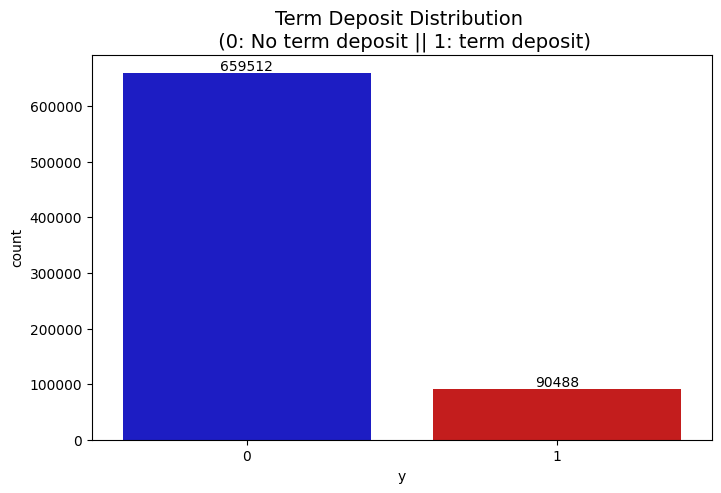

In [12]:
# visualize class imbalance
plt.figure(figsize=(8, 5))

ax = sns.countplot(x=target, data=train, palette=["#0101DF", "#DF0101"], hue=target, legend=False)

# Add the count labels above each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title('Term Deposit Distribution \n (0: No term deposit || 1: term deposit)', fontsize=14)

plt.show()

We will implement a hybrid resampling strategy that balances the dataset by simultaneously reducing the majority group and increasing the minority group. This approach creates two equal sets of `329756` samples to ensure the model learns from both outcomes with equal priority. 

Shuffling the final combined records prevents any order bias during the training phase.

In [13]:
deposit = deposit = train.loc[train[target] == 1]
non_deposit = train.loc[train[target] == 0]

In [14]:
# hybrid approach - upsample minority class and downsample majority class
target_class_size = len(non_deposit) // 2

# Downsample the majority class to be as small as the class size.
non_deposit_hybrid = resample(
                        non_deposit, 
                        replace=False,
                        n_samples=target_class_size,                random_state=27)

# Upsample the minority class to be as big as the class size.
deposit_hybrid = resample(
                    deposit, 
                    replace=True,
                    n_samples=target_class_size,                           random_state=27)

# Combine
train_df = pd.concat([non_deposit_hybrid, deposit_hybrid])

# Lets shuffle the data
train_df = train_df.sample(frac=1, random_state=27)

# Check new class counts
train_df[target].value_counts()

y
0    329756
1    329756
Name: count, dtype: int64

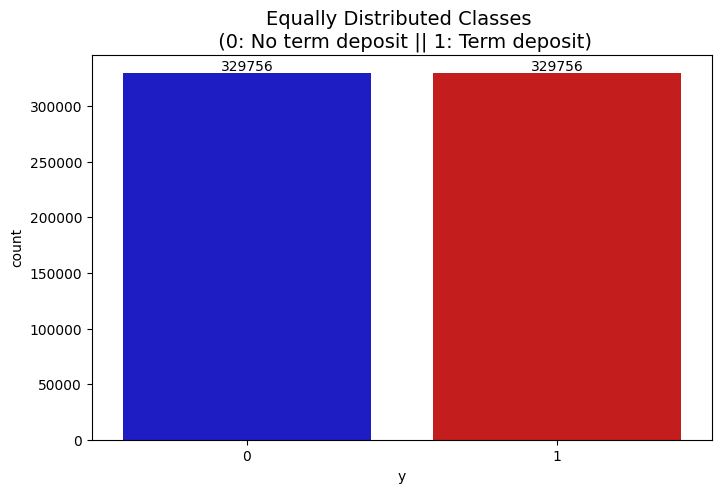

In [15]:
# visualize the equally distributed classes
plt.figure(figsize=(8, 5))

ax = sns.countplot(x=target, data=train_df, palette=["#0101DF", "#DF0101"], hue=target, legend=False)

# Add the count labels above each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title('Equally Distributed Classes \n (0: No term deposit || 1: Term deposit)', fontsize=14)

plt.show()

## 6. Split and scale data

Let us prepare our data for training models by:
- Partitioning the training data into independent predictor variables and the target classification label. 
- Applying a stratified split to ensure both training and validation sets maintain identical proportions of subscription outcomes for consistent performance measurement. 
- Using standard scaling to normalize feature magnitudes and prevent variables with larger ranges from dominating the learning process.

In [16]:
# define the predictors and label
X = train_df.drop(target, axis=1)
y = train_df[target]

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=27)

# scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
test_scaled = scaler.transform(test)



## 7. Training models

We evaluate several algorithms and identify the Ridge Regression as the primary model due to its superior performance on the `roc_auc_score`.

### 7.1. Ridge Regression - winner/top predictor

This model achieves the highest predictive accuracy ([kaggle](https://www.kaggle.com/competitions/binary-classification-with-a-bank-dataset-clone/leaderboard#) score of `0.94654`) using unscaled values.

In [ ]:
# Create ridge model with alpha = 1
ridge = Ridge(alpha=1)

# Train the model
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Clip values to be between 0 and 1
roc_auc_score(y_test, np.clip(ridge_pred, 1e-15, 1 - 1e-15))

# 0.9448844680891731 - roc_auc_score


0.9448971344252824

We then make predictions on the submission file, clip the otput values between zero and one to satisfy [kaggle's competition](https://www.kaggle.com/competitions/binary-classification-with-a-bank-dataset-clone/overview) requirements and ensure the results remain within logical probability boundaries. 

In [ ]:
# Predict on the test data
ridge_sub = ridge.predict(test)

# Clip to [0, 1] to meet kaggle's probability requirement
ridge_submission_probs = np.clip(ridge_sub, 0, 1)

# Format and save
ridge_submission = pd.DataFrame({
    'id': test.index, 
    'y': ridge_submission_probs
})
ridge_submission.to_csv('submissions/ridge_submission.csv', index=False)

# 0.94654 - kaggle score

Export the final Ridge model for deployment. This step ensures that the trained logic can be loaded or integrated into external applications.

In [ ]:
# save model for deployment
joblib.dump(ridge, 'app_template/pickles/back_asset_insights_model.pkl')


['app_template/pickles/back_asset_insights_model.pkl']

These other models performed significantly below the Ridge model. This performance gap confirms the selected regression approach as the most reliable solution for predicting customer subscription intent.

### 7.2. Logistic Regression

We use standardized data to establish a performance baseline. This iteration achieves a score of `0.8815`which remains significantly below the Ridge model results.

In [ ]:
# instantiate model
logistic = LogisticRegression(
    C=1.0,               
    solver='lbfgs',      
    max_iter=1000,       
    random_state=42,         
)

# Train the model
logistic.fit(X_train_scaled, y_train)
logistic_pred = logistic.predict(X_test_scaled)

# Clip values to be between 0 and 1
roc_auc_score(y_test, np.clip(logistic_pred, 1e-15, 1 - 1e-15))

# 0.8815112175161052

0.8815112175161052

### 7.3. XGBoost Classifier

While this ensemble method reaches a strong kaggle score of point `0.90688`, it still falls significantly below the Ridge model results.

In [ ]:
# instantiate model
xgb = XGBClassifier(
    n_estimators=300,           
    learning_rate=0.05,         
    max_depth=11,                
    subsample=0.8,              
    colsample_bytree=0.8,       
    objective='binary:logistic',
    random_state=42,            
    n_jobs=-1,
    tree_method='hist'                   
)

# Train the model
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)


# Clip values to be between 0 and 1
roc_auc_score(y_test, np.clip(xgb_pred, 1e-15, 1 - 1e-15))

# 0.9332461218266888 - roc_auc_score

0.9332461218266888

The XGB predictions on submission file:

In [ ]:
# Predict on the submission test data
xgb_sub = xgb.predict(test_scaled)

# Clip to [0, 1] 
xgb_submission_probs = np.clip(xgb_sub, 0, 1)

# Format and save
xgb_submission = pd.DataFrame({
    'id': test.index, 
    'y': xgb_submission_probs
})
xgb_submission.to_csv('submissions/xgb_submission.csv', index=False)

# 0.90688 - kaggle score

### 7.4. Random Forest Classifier

This model achieves a `roc_auc_score` of `0.89447`, which remains significantly below the Ridge model results.

In [ ]:
# instantiate model
rf = RandomForestClassifier(
    n_estimators=300,              
    max_depth=10,         
    min_samples_split=2,    
    min_samples_leaf=1,     
    max_features='sqrt',    
    bootstrap=True,         
    oob_score=True,         
    n_jobs=-1,              
    random_state=42         
)

# Train the model
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

# Clip values to be between 0 and 1
roc_auc_score(y_test, np.clip(rf_pred, 1e-15, 1 - 1e-15))
# 0.8944675164721893 - roc_auc_score

0.8944675164721893

### 7.5. KNeighbors Classifier

With a kaggle score of point `0.87578`, this model also falls significantly below the Ridge model results.

In [ ]:
# instantiate the model
knn = KNeighborsClassifier(n_neighbors=12, weights='distance', metric='minkowski')

# Train the model
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# Clip values to be between 0 and 1
roc_auc_score(y_test, np.clip(knn_pred, 1e-15, 1 - 1e-15))

# 0.9254901746660518 - roc_auc_score

0.9254901746660518

In [ ]:
# Predict on the submission test data
knn_sub = knn.predict(test_scaled)
# knn_sub = knn.predict(test)

# Clip to [0, 1] 
knn_submission_probs = np.clip(knn_sub, 0, 1)

# Format and save
knn_submission = pd.DataFrame({
    'id': test.index, 
    'y': knn_submission_probs
})
knn_submission.to_csv('submissions/knn_submission.csv', index=False)

#  0.87578 - kaggle

## 8. Conclusion

We finalize the project by deploying the best predictive model as a functional Streamlit application. This web interface allows stakeholders to input customer data and receive instant propensity scores to drive real time decision making. 

The successful transition from a high performing Ridge model to a live production environment provides a scalable solution for banking institutions to optimize their marketing efforts and improve long term deposit growth.

© 2026 **[Erick Gathinji](https://www.linkedin.com/in/erick-gathinji/)**